# 01 — STATS19 Exploratory Data Analysis

Covers:
- Missingness / data quality
- Collision severity distributions  
- Temporal trends (year, month, day of week, hour)
- Vehicle type breakdown
- Join quality (collision → vehicle → casualty)

**Geography:** Yorkshire (police forces 4, 5, 6, 7)  
**Years:** 2015–2024


## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from road_risk.config import _ROOT
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted")

YEARS = list(range(2015, 2025))
COVID_YEARS = [2020, 2021]

In [20]:
df_guide = pd.read_excel(
    _ROOT / "data/raw/stats19/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx",
    sheet_name="2024_code_list"
)
df_guide.columns = ["table", "field_name", "code", "label", "note"]

def get_lookup(field: str) -> dict:
    """Return code→label dict for any STATS19 field."""
    rows = df_guide[df_guide["field_name"] == field].dropna(subset=["code", "label"])
    return dict(zip(rows["code"].astype(int), rows["label"]))

In [3]:
from road_risk.ingest.ingest_stats19 import load_stats19, join_stats19
from road_risk.config import _ROOT

data = load_stats19(raw_folder=_ROOT / "data/raw/stats19", years=YEARS)
collisions = data["collision"]
vehicles   = data["vehicle"]
casualties = data["casualty"]

    Expected columns missing in dft-road-casualty-statistics-collision-1979-latest-published-year.csv: ['collision_date']


In [4]:
data.keys()

dict_keys(['collision', 'vehicle', 'casualty'])

## 1. Missingness & Data Quality

Check each table for missing values and obvious data issues.

In [5]:
def missingness_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    total = len(df)
    report = (
        df.isnull().sum()
        .rename("n_missing")
        .to_frame()
        .assign(pct_missing=lambda x: 100 * x["n_missing"] / total)
        .query("n_missing > 0")
        .sort_values("pct_missing", ascending=False)
    )
    print(f"\n{'='*50}")
    print(f"{name}: {total:,} rows — {len(report)} cols with missing values")
    return report

miss_c = missingness_report(collisions, "Collisions")
miss_v = missingness_report(vehicles,   "Vehicles")
miss_k = missingness_report(casualties, "Casualties")
display(miss_c.head(15))


Collisions: 102,361 rows — 5 cols with missing values

Vehicles: 187,542 rows — 0 cols with missing values

Casualties: 136,379 rows — 0 cols with missing values


,n_missing,pct_missing
location_easting_osgr,44,0.043
location_northing_osgr,44,0.043
longitude,44,0.043
latitude,44,0.043
local_authority_highway_current,44,0.043


In [6]:
# Flag rows with missing lat/lon — these can't be spatially joined
bad_geo = collisions[collisions[["latitude", "longitude"]].isnull().any(axis=1)]
print(f"Collisions missing lat/lon: {len(bad_geo):,} ({100*len(bad_geo)/len(collisions):.2f}%)")

# Check lat/lon plausibility — Yorkshire bbox
in_bbox = (
    collisions["latitude"].between(53.30, 54.60) &
    collisions["longitude"].between(-2.20, -0.08)
)
out_bbox = collisions[collisions[["latitude","longitude"]].notna().all(axis=1) & ~in_bbox]
print(f"Collisions with valid coords outside Yorkshire bbox: {len(out_bbox):,}")

Collisions missing lat/lon: 44 (0.04%)
Collisions with valid coords outside Yorkshire bbox: 2,269


In [7]:
# Speed limit sanity check
print("Speed limit distribution:")
print(collisions["speed_limit"].value_counts().sort_index())

Speed limit distribution:
speed_limit
20.000     4998
30.000    64872
40.000    11068
50.000     2627
60.000    13088
70.000     5708
Name: count, dtype: int64


## 2. Collision Severity Distributions

STATS19 severity codes: 1 = Fatal, 2 = Serious, 3 = Slight

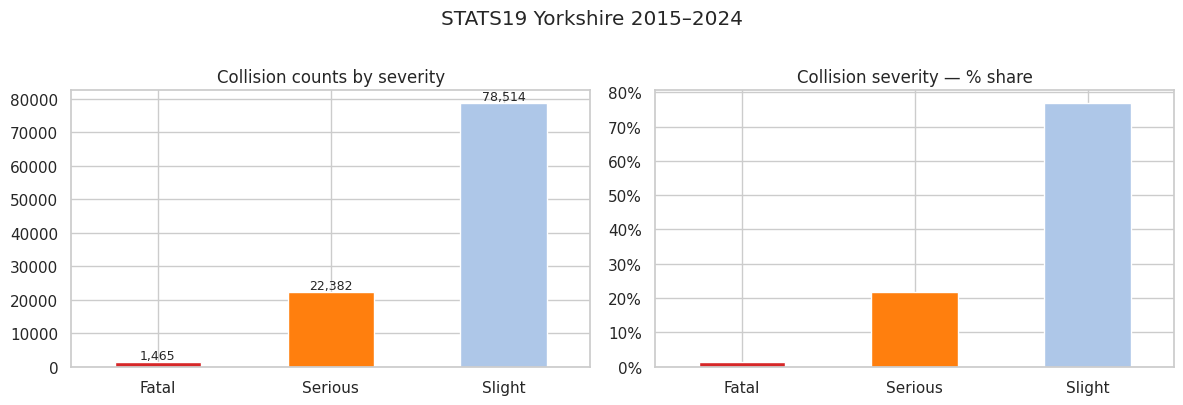

In [8]:
severity_map = {1: "Fatal", 2: "Serious", 3: "Slight"}
collisions["severity_label"] = collisions["collision_severity"].map(severity_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall counts
counts = collisions["severity_label"].value_counts().reindex(["Fatal", "Serious", "Slight"])
counts.plot(kind="bar", ax=axes[0], color=["#d62728", "#ff7f0e", "#aec7e8"], edgecolor="white")
axes[0].set_title("Collision counts by severity")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)

# Proportions
props = counts / counts.sum() * 100
props.plot(kind="bar", ax=axes[1], color=["#d62728", "#ff7f0e", "#aec7e8"], edgecolor="white")
axes[1].set_title("Collision severity — % share")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("STATS19 Yorkshire 2015–2024", y=1.01)
plt.tight_layout()
plt.show()

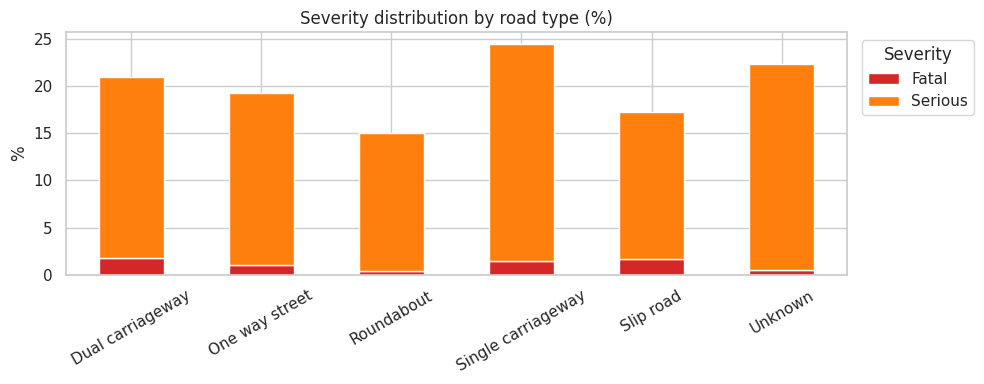

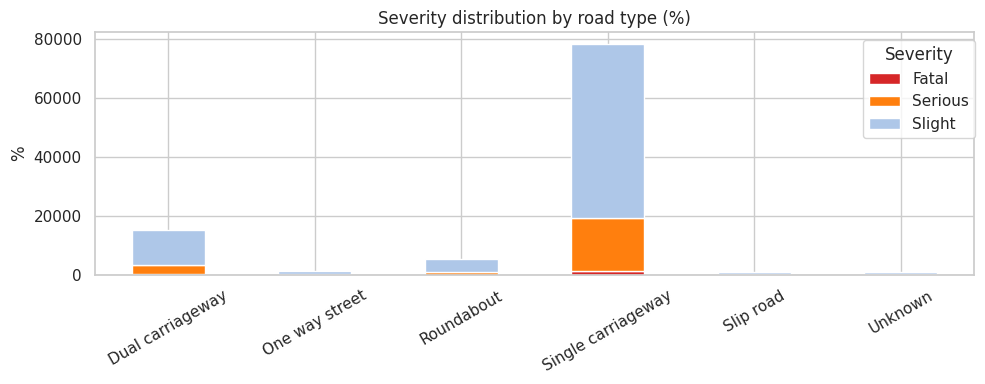

In [9]:
# Severity by road type
road_type_lookup = get_lookup("road_type")
collisions["road_type_label"] = collisions["road_type"].map(road_type_lookup)

sev_road = (
    collisions.groupby(["road_type_label", "severity_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Fatal", "Serious", "Slight"])
)
sev_road_pct = sev_road.div(sev_road.sum(axis=1), axis=0) * 100

sev_road_pct.iloc[:, :2].plot(kind="bar", stacked=True, figsize=(10, 4),
                  color=["#d62728", "#ff7f0e", "#aec7e8"], edgecolor="white")
plt.title("Severity distribution by road type (%)")
plt.xlabel("")
plt.ylabel("%")
plt.legend(title="Severity", bbox_to_anchor=(1.01, 1))
plt.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

sev_road.plot(kind="bar", stacked=True, figsize=(10, 4),
                  color=["#d62728", "#ff7f0e", "#aec7e8"], edgecolor="white")
plt.title("Severity distribution by road type (%)")
plt.xlabel("")
plt.ylabel("%")
plt.legend(title="Severity", bbox_to_anchor=(1.01, 1))
plt.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

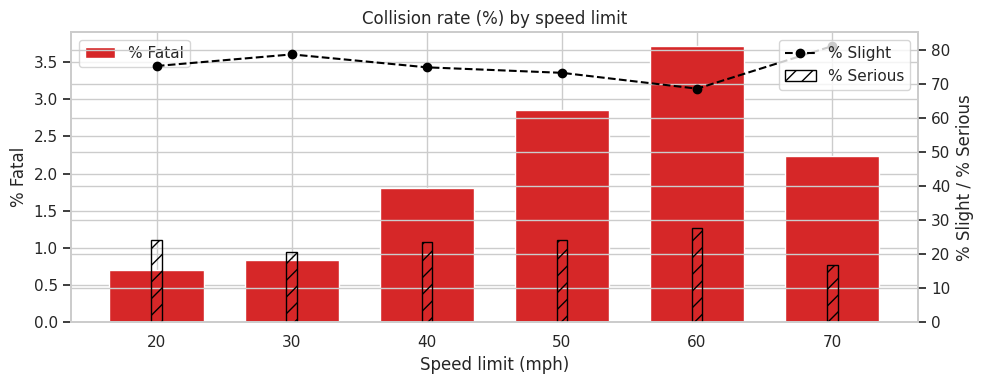

In [10]:
# Severity by speed limit
sev_speed = (
    collisions.groupby(["speed_limit", "severity_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Fatal", "Serious", "Slight"])
)
fatal_rate = sev_speed["Fatal"] / sev_speed.sum(axis=1) * 100
serious_rate = sev_speed["Serious"] / sev_speed.sum(axis=1) * 100
slight_rate = sev_speed["Slight"] / sev_speed.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 4))
axR = ax.twinx()

# slight_rate.plot(kind="line", ax=axR, color="#1f77b4")
axR.plot(
    slight_rate.index,
    slight_rate.values,
    color="black",
    linestyle="--",
    marker="o",
    label="% Slight",
)
axR.bar(
    serious_rate.index,
    serious_rate.values,
    color="none",
    edgecolor="black",
    hatch="//",
    label="% Serious",
)
ax.bar(
    fatal_rate.index,
    fatal_rate.values,
    color="#d62728",
    edgecolor="white",
    label="% Fatal",
    width=7,
)

ax.set_title("Collision rate (%) by speed limit")
ax.set_xlabel("Speed limit (mph)")
ax.set_ylabel("% Fatal")
axR.set_ylabel("% Slight / % Serious")
ax.tick_params(axis="x", rotation=0)
axR.legend(loc="upper right")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3. Temporal Trends

Year-on-year trend, monthly seasonality, day-of-week and hour-of-day patterns.
COVID years (2020–2021) flagged throughout.

In [11]:
collisions.keys()

Index(['collision_index', 'collision_year', 'collision_ref_no',
       'location_easting_osgr', 'location_northing_osgr', 'longitude',
       'latitude', 'police_force', 'collision_severity', 'number_of_vehicles',
       'number_of_casualties', 'date', 'day_of_week', 'time',
       'local_authority_district', 'local_authority_ons_district',
       'local_authority_highway', 'local_authority_highway_current',
       'first_road_class', 'first_road_number', 'road_type', 'speed_limit',
       'junction_detail_historic', 'junction_detail', 'junction_control',
       'second_road_class', 'second_road_number',
       'pedestrian_crossing_human_control_historic',
       'pedestrian_crossing_physical_facilities_historic',
       'pedestrian_crossing', 'light_conditions', 'weather_conditions',
       'road_surface_conditions', 'special_conditions_at_site',
       'carriageway_hazards_historic', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
 

In [12]:
# Parse date — column is 'date' not 'collision_date'
if not pd.api.types.is_datetime64_any_dtype(collisions["date"]):
    collisions["date"] = pd.to_datetime(collisions["date"], dayfirst=True, errors="coerce")

collisions["year"]  = collisions["collision_year"]  # already exists
collisions["month"] = collisions["date"].dt.month
# day_of_week already exists as a column — but it's coded (1-7), add label version
collisions["day_name"] = collisions["date"].dt.day_name()
collisions["hour"] = pd.to_datetime(
    collisions["time"], format="%H:%M", errors="coerce"
).dt.hour

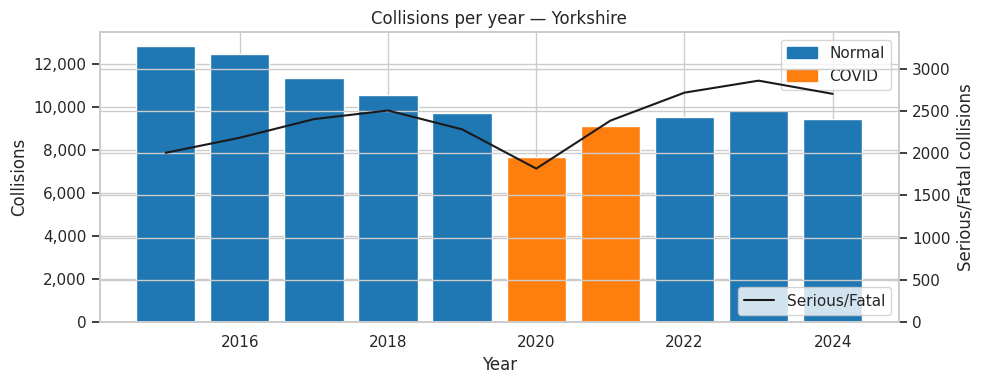

In [13]:
# Year-on-year collision counts
yearly = collisions.groupby("year").size().reset_index(name="n_collisions")
yearly["is_covid"] = yearly["year"].isin(COVID_YEARS)

cond_ser = (collisions["severity_label"] == "Fatal") | (collisions["severity_label"] == "Serious")
yearly_serious = collisions[cond_ser].groupby("year").size().reset_index(name="n_serious")
# yearly_serious["is_covid"] = yearly_serious["year"].isin(COVID_YEARS)


fig, ax = plt.subplots(figsize=(10, 4))
axR = ax.twinx()

colors = ["#ff7f0e" if covid else "#1f77b4" for covid in yearly["is_covid"]]
axR.plot(yearly_serious["year"], yearly_serious["n_serious"], color="k", label="Serious/Fatal")

bars = ax.bar(yearly["year"], yearly["n_collisions"], color=colors, edgecolor="white")

ax.set_title("Collisions per year — Yorkshire")
ax.set_xlabel("Year")
ax.set_ylabel("Collisions")
axR.set_ylabel("Serious/Fatal collisions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axR.legend(loc="lower right")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#1f77b4", label="Normal"),
    Patch(color="#ff7f0e", label="COVID")
])
axR.set_ylim(0, yearly_serious["n_serious"].max() * 1.2)
plt.tight_layout()
plt.show()

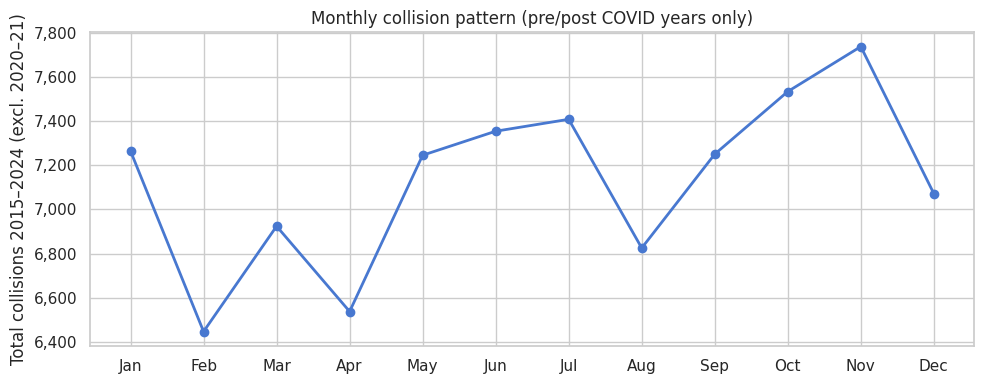

In [14]:
# Monthly seasonality (excluding COVID years)
monthly = (
    collisions[~collisions["year"].isin(COVID_YEARS)]
    .groupby("month")
    .size()
    .reset_index(name="n_collisions")
)
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["month"], monthly["n_collisions"], marker="o", linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title("Monthly collision pattern (pre/post COVID years only)")
ax.set_ylabel("Total collisions 2015–2024 (excl. 2020–21)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [15]:
collisions["day_of_week"]

300        6
339        6
340        3
387        7
466        7
          ..
9009015    1
9011322    3
9011668    6
9012107    7
9013490    5
Name: day_of_week, Length: 102361, dtype: int64

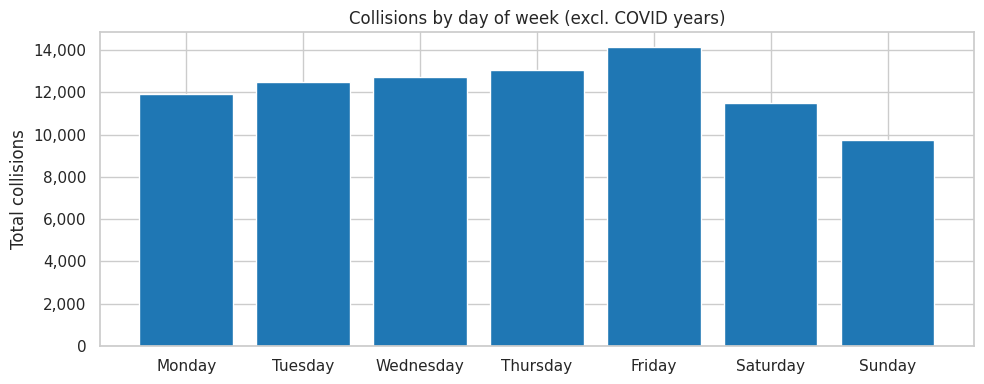

In [16]:
# Day of week
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = (
    collisions[~collisions["year"].isin(COVID_YEARS)]
    .groupby("day_name")
    .size()
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dow.index, dow.values, color="#1f77b4", edgecolor="white")
ax.set_title("Collisions by day of week (excl. COVID years)")
ax.set_ylabel("Total collisions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

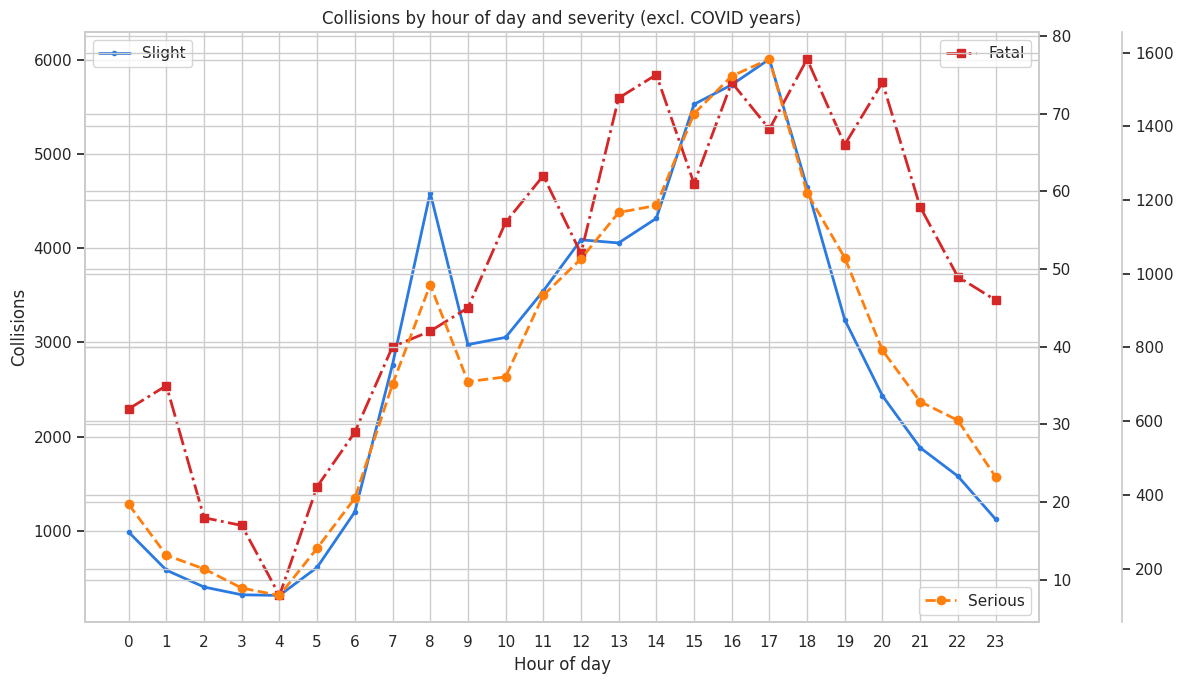

In [17]:
# Hour of day — by severity
if collisions["hour"].notna().sum() > 0:
    hourly = (
        collisions[~collisions["year"].isin(COVID_YEARS)]
        .groupby(["hour", "severity_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Fatal", "Serious", "Slight"])
    )
    fig, ax = plt.subplots(figsize=(12, 7))
    axRight = ax.twinx()
    # 2nd right y axis shifted slightly
    axRightFar = ax.twinx()
    axRightFar.spines["right"].set_position(("outward", 60))
    for col, color, linestyle, marker in zip(
        ["Slight", "Serious", "Fatal"],
        ["#2b7ae1", "#ff7f0e", "#d62728"],
        ["-", "--", "-."],
        [".", "o", "s"],
    ):
        if col in hourly:
            if col == "Slight":
                ax.plot(
                    hourly.index,
                    hourly[col],
                    label=col,
                    color=color,
                    linewidth=2,
                    linestyle=linestyle,
                    marker=marker,
                )
            elif col == "Fatal":
                axRight.plot(
                    hourly.index,
                    hourly[col],
                    label=col,
                    color=color,
                    linewidth=2,
                    linestyle=linestyle,
                    marker=marker,
                )
            else:
                axRightFar.plot(
                    hourly.index,
                    hourly[col],
                    label=col,
                    color=color,
                    linewidth=2,
                    linestyle=linestyle,
                    marker=marker,
                )
    ax.set_title("Collisions by hour of day and severity (excl. COVID years)")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Collisions")
    ax.set_xticks(range(0, 24))
    ax.legend(loc="upper left")
    axRight.legend(
        loc="upper right",
    )
    axRightFar.legend(
        loc="lower right",
    )
    plt.tight_layout()
    plt.show()
else:
    print("No time data available — check 'time' column name in your files")

## 4. Vehicle Type Breakdown

In [21]:


# Then in the notebook:
vtype_lookup = get_lookup("vehicle_type")
vehicles["vehicle_type_label"] = vehicles["vehicle_type"].map(vtype_lookup)
print(vtype_lookup)

{1: 'Pedal cycle', 2: 'Motorcycle 50cc and under', 3: 'Motorcycle 125cc and under', 4: 'Motorcycle over 125cc and up to 500cc', 5: 'Motorcycle over 500cc', 8: 'Taxi/Private hire car', 9: 'Car', 10: 'Minibus (8 - 16 passenger seats)', 11: 'Bus or coach (17 or more pass seats)', 16: 'Ridden horse', 17: 'Agricultural vehicle', 18: 'Tram', 19: 'Van / Goods 3.5 tonnes mgw or under', 20: 'Goods over 3.5t. and under 7.5t', 21: 'Goods 7.5 tonnes mgw and over', 22: 'Mobility scooter', 23: 'Electric motorcycle', 90: 'Other vehicle', 97: 'Motorcycle - unknown cc', 98: 'Goods vehicle - unknown weight', 99: 'Unknown vehicle type (self rep only)', 103: 'Motorcycle - Scooter (1979-1998)', 104: 'Motorcycle (1979-1998)', 105: 'Motorcycle - Combination (1979-1998)', 106: 'Motorcycle over 125cc (1999-2004)', 108: 'Taxi (excluding private hire cars) (1979-2004)', 109: 'Car (including private hire cars) (1979-2004)', 110: 'Minibus/Motor caravan (1979-1998)', 113: 'Goods over 3.5 tonnes (1979-1998)', -1: 'D

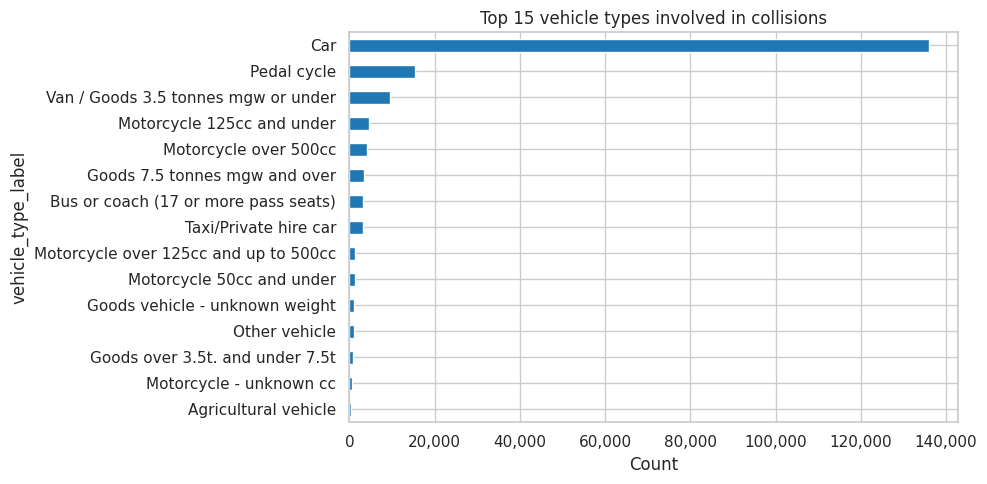

In [22]:
# Vehicle type distribution
vtype_counts = vehicles["vehicle_type_label"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
vtype_counts.plot(kind="barh", ax=ax, color="#1f77b4", edgecolor="white")
ax.set_title("Top 15 vehicle types involved in collisions")
ax.set_xlabel("Count")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [23]:
# HGV involvement rate by road type
# Join vehicle back to collision to get road_type
veh_with_road = vehicles.merge(
    collisions[["collision_index", "road_type", "collision_severity"]],
    on="collision_index", how="left"
)

# Flag HGV involvement (vehicle_type codes 3=HGV, 4=bus — check your data guide)
# Using a broad definition — adjust codes once you've checked the data guide
HGV_TYPES = [3, 11, 20, 21, 98]  # adjust per STATS19 data guide
veh_with_road["is_hgv"] = veh_with_road["vehicle_type"].isin(HGV_TYPES)

hgv_by_road = (
    veh_with_road.groupby("road_type")["is_hgv"]
    .agg(["sum", "count"])
    .assign(hgv_pct=lambda x: 100 * x["sum"] / x["count"])
    .sort_values("hgv_pct", ascending=False)
)
print("HGV involvement % by road type:")
display(hgv_by_road)

HGV involvement % by road type:


,sum,count,hgv_pct
road_type,,,
3,3064,30433,10.068
2,190,2179,8.720
7,150,2008,7.470
1,691,10387,6.653
6,9016,140992,6.395
9,93,1543,6.027


Vehicles per collision — mean: 1.83, max: 16


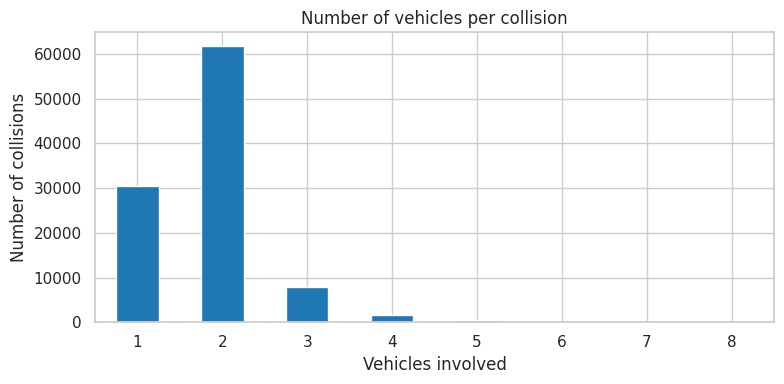

In [24]:
# Vehicles per collision distribution
veh_per_collision = vehicles.groupby("collision_index").size()
print(f"Vehicles per collision — mean: {veh_per_collision.mean():.2f}, "
      f"max: {veh_per_collision.max()}")

fig, ax = plt.subplots(figsize=(8, 4))
veh_per_collision.value_counts().sort_index().head(8).plot(
    kind="bar", ax=ax, color="#1f77b4", edgecolor="white"
)
ax.set_title("Number of vehicles per collision")
ax.set_xlabel("Vehicles involved")
ax.set_ylabel("Number of collisions")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 5. Join Quality

How well do the three STATS19 tables link together?
Are there orphaned vehicle/casualty records?

In [25]:
collision_ids = set(collisions["collision_index"])
vehicle_ids   = set(vehicles["collision_index"])
casualty_ids  = set(casualties["collision_index"])

print("=== Join coverage ===")
print(f"Collision IDs                         : {len(collision_ids):,}")
print()
print(f"Vehicle records                       : {len(vehicles):,}")
print(f"  → matched to a collision            : {len(vehicle_ids & collision_ids):,}"
      f"  ({100*len(vehicle_ids & collision_ids)/len(vehicle_ids):.1f}%)")
print(f"  → orphaned (no collision match)     : {len(vehicle_ids - collision_ids):,}")
print()
print(f"Casualty records                      : {len(casualties):,}")
print(f"  → matched to a collision            : {len(casualty_ids & collision_ids):,}"
      f"  ({100*len(casualty_ids & collision_ids)/len(casualty_ids):.1f}%)")
print(f"  → orphaned (no collision match)     : {len(casualty_ids - collision_ids):,}")
print()
print(f"Collisions with no vehicles           : {len(collision_ids - vehicle_ids):,}")
print(f"Collisions with no casualties         : {len(collision_ids - casualty_ids):,}")

=== Join coverage ===
Collision IDs                         : 102,361

Vehicle records                       : 187,542
  → matched to a collision            : 102,361  (100.0%)
  → orphaned (no collision match)     : 0

Casualty records                      : 136,379
  → matched to a collision            : 102,361  (100.0%)
  → orphaned (no collision match)     : 0

Collisions with no vehicles           : 0
Collisions with no casualties         : 0


In [26]:
# Full join and check for unexpected row explosion
joined = join_stats19(data)
print(f"\nJoined table: {len(joined):,} rows × {joined.shape[1]} cols")
print(f"Expected (≈ n_casualties): {len(casualties):,}")
print(f"Ratio joined/casualties  : {len(joined)/len(casualties):.3f}  (should be ~1.0)")


Joined table: 263,474 rows × 104 cols
Expected (≈ n_casualties): 136,379
Ratio joined/casualties  : 1.932  (should be ~1.0)


In [27]:
# Check for duplicate column name collisions after join
dup_cols = [c for c in joined.columns if joined.columns.tolist().count(c) > 1]
if dup_cols:
    print(f"Duplicate columns after join: {dup_cols}")
else:
    print("No duplicate column names after join ✓")

# Null rates on key joined columns
key_cols = ["collision_index", "collision_severity", "vehicle_type",
            "casualty_severity", "casualty_type"]
for col in key_cols:
    if col in joined.columns:
        n_null = joined[col].isnull().sum()
        print(f"  {col:35s}: {n_null:,} nulls ({100*n_null/len(joined):.1f}%)")

No duplicate column names after join ✓
  collision_index                    : 0 nulls (0.0%)
  collision_severity                 : 0 nulls (0.0%)
  vehicle_type                       : 0 nulls (0.0%)
  casualty_severity                  : 0 nulls (0.0%)
  casualty_type                      : 0 nulls (0.0%)


In [28]:
# How many casualties actually belong to Yorkshire collisions?
yorks_casualties = casualties[casualties["collision_index"].isin(collision_ids)]
print(f"Yorkshire casualties: {len(yorks_casualties):,}")
print(f"Joined rows:          {len(joined):,}")
print(f"Ratio:                {len(joined)/len(yorks_casualties):.3f}  (should be ~1.0 now)")

Yorkshire casualties: 136,379
Joined rows:          263,474
Ratio:                1.932  (should be ~1.0 now)


## 6. Summary & Notes for clean.py

Fill this in after running the notebook:

- **Missing lat/lon:** _n_ rows to drop
- **Out-of-bbox coordinates:** _n_ rows to investigate  
- **Speed limit outliers:** values to recode as null
- **HGV vehicle type codes:** confirm codes from data guide
- **COVID flag:** years 2020–2021 to be flagged in features.py
- **Join orphans:** _n_ vehicle / _n_ casualty records unmatched — investigate
